In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import keras
import re
import os
from keras import Input
from keras.models import Model
import cv2
import tensorflow as tf
from sklearn.metrics import multilabel_confusion_matrix

In [3]:
data = pd.read_csv("/kaggle/input/data/Data_Entry_2017.csv")

In [4]:
path = '/kaggle/input/data/'



In [5]:
main_dir = os.listdir(path)

In [6]:
main_dir = [s for s in main_dir if s.startswith("image")]

In [7]:
main_dir.sort()

In [8]:
main_dir = [path + s + "/images" for s in main_dir ]

In [9]:
a = os.listdir("/kaggle/input/data/images_001/images")
a.sort()

In [10]:
img_name = []
for item in main_dir:
    l = os.listdir(item)
    l.sort()
    img_name.append(l)
        

In [11]:
img_location = np.array([])
for i in range(len(img_name)):
    a = np.array(img_name[i], dtype = object)
    a = main_dir[i] + '/' +  a
    img_location = np.append(img_location, a.astype('str'))

In [12]:
img_name = np.concatenate([s for s in img_name])

In [13]:
data.iloc[:10]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN
5,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,0.168,0.168,NaN
6,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,0.168,0.168,NaN
7,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,0.143,NaN
8,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,0.168,0.168,NaN
9,00000003_005.png,Hernia,5,3,78,F,PA,2686,2991,0.143,0.143,NaN


In [14]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), object(4)
memory usage: 10.3+ MB


In [15]:
unique = set()
def unique_disease(x):
    for i in x:
        unique.add(i)

pd.Series(data['Finding Labels'].unique()).apply(lambda x : unique_disease(x.split('|')))

0      None
1      None
2      None
3      None
4      None
       ... 
831    None
832    None
833    None
834    None
835    None
Length: 836, dtype: object

In [16]:
unique.remove('No Finding')

In [17]:
unique = list(unique)
unique.sort()

In [18]:
unique

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [19]:
len(unique)

14

In [20]:
unique = (zip(unique,range(len(unique))))
unique = dict(unique)
unique

{'Atelectasis': 0,
 'Cardiomegaly': 1,
 'Consolidation': 2,
 'Edema': 3,
 'Effusion': 4,
 'Emphysema': 5,
 'Fibrosis': 6,
 'Hernia': 7,
 'Infiltration': 8,
 'Mass': 9,
 'Nodule': 10,
 'Pleural_Thickening': 11,
 'Pneumonia': 12,
 'Pneumothorax': 13}

In [21]:
one_hot_encoded = np.eye(len(unique))

In [22]:
def multi_hot_encoder(x):
    temp = np.zeros((1,one_hot_encoded.shape[0]))
    for i in x:
        if i == 'No Finding':
            return np.zeros((1,14))
        temp[0] = temp[0] + one_hot_encoded[unique[i]]
    return temp

In [23]:
multi_hot_encoded_vector = data['Finding Labels'].apply(lambda x : multi_hot_encoder(x.split('|')))
multi_hot_encoded_vector = np.concatenate(multi_hot_encoded_vector.values)

In [24]:
multi_hot_encoded_vector[:5]

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])

In [25]:
X_train = pd.DataFrame(img_location, columns = ['img_location'])

In [26]:
X_train['Finding Labels'] = data['Finding Labels']
X_train['img_name'] = img_name
X_train['Patient ID'] = data['Patient ID']

In [27]:
X_train = pd.concat([X_train,pd.DataFrame(multi_hot_encoded_vector)], axis = 1)

In [28]:
X_train = X_train.sample(X_train.shape[0])

In [29]:
y_train = X_train.iloc[:,4:]

In [30]:
y_train

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
5862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
67609,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90574,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
61089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31313,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59821,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
78710,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
83683,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
X_train = X_train.iloc[:,:4]

In [32]:
X_train

,img_location,Finding Labels,img_name,Patient ID
5862,/kaggle/input/data/images_002/images/00001582_...,Infiltration,00001582_003.png,1582
67609,/kaggle/input/data/images_008/images/00016715_...,No Finding,00016715_007.png,16715
32557,/kaggle/input/data/images_004/images/00008515_...,No Finding,00008515_005.png,8515
90574,/kaggle/input/data/images_010/images/00022559_...,No Finding,00022559_006.png,22559
61089,/kaggle/input/data/images_007/images/00015069_...,Infiltration|Pneumonia,00015069_001.png,15069
...,...,...,...,...
31313,/kaggle/input/data/images_004/images/00008168_...,No Finding,00008168_012.png,8168
59821,/kaggle/input/data/images_007/images/00014771_...,Infiltration|Pneumonia,00014771_004.png,14771
78710,/kaggle/input/data/images_009/images/00019308_...,Infiltration,00019308_012.png,19308
83683,/kaggle/input/data/images_009/images/00020531_...,No Finding,00020531_000.png,20531


In [33]:
y_train

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
5862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
67609,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90574,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
61089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31313,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59821,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
78710,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
83683,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
X_train = X_train.reset_index()
y_train = y_train.reset_index()

In [35]:
X_train.drop(['index'], inplace = True, axis =1)
y_train.drop(['index'], inplace = True, axis = 1)

In [36]:
X_train.head()

,img_location,Finding Labels,img_name,Patient ID
0,/kaggle/input/data/images_002/images/00001582_...,Infiltration,00001582_003.png,1582
1,/kaggle/input/data/images_008/images/00016715_...,No Finding,00016715_007.png,16715
2,/kaggle/input/data/images_004/images/00008515_...,No Finding,00008515_005.png,8515
3,/kaggle/input/data/images_010/images/00022559_...,No Finding,00022559_006.png,22559
4,/kaggle/input/data/images_007/images/00015069_...,Infiltration|Pneumonia,00015069_001.png,15069


In [37]:
y_train = y_train.astype(int)

In [38]:
class_balance = dict(zip(y_train.columns,range(y_train.shape[1]+1)))
for i in y_train.columns:
    class_balance[i] = y_train[y_train[i] == 1].shape[0]

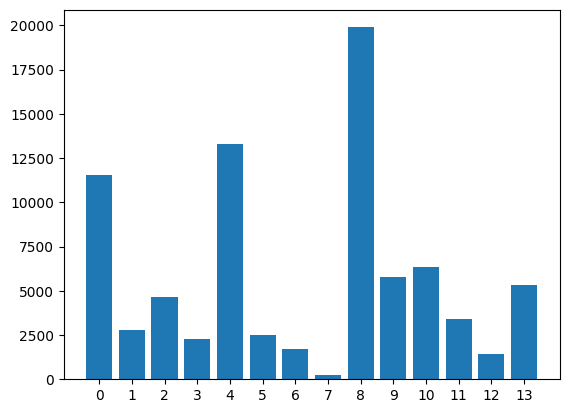

In [39]:
plt.bar(x = class_balance.keys(), height = class_balance.values())
plt.xticks(list(range(14)))
plt.show()

In [40]:
y_train.iloc[:78484][5].sum()

1740

# ***Data Generator***

In [41]:
import cv2

In [42]:
a = cv2.resize(cv2.imread(X_train['img_location'][0]), (224,224,), interpolation = cv2.INTER_CUBIC)

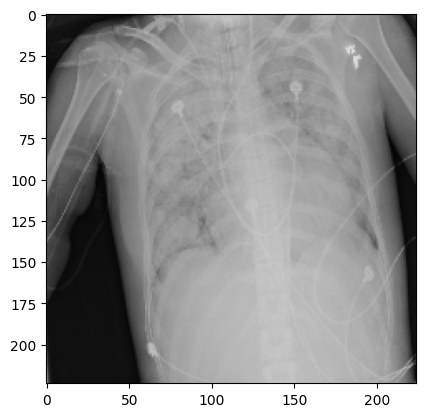

In [43]:
plt.imshow(a)

In [44]:
def nn_train_gen(X_train, y_train, batch_size):

    shuffled_index = np.random.permutation(range(X_train.shape[0]))
    pointer_location = 0

    y_train = y_train.to_numpy()
    
    X_mini_batch_shape = (batch_size, 224, 224, 3)
    X_mini_batch = np.zeros(shape = X_mini_batch_shape)
    y_mini_batch = np.zeros(shape = (batch_size, 14))

    while True:

        for j in range(batch_size):
            
            X_mini_batch[j] = cv2.resize(cv2.imread(X_train['img_location'][shuffled_index[pointer_location]]),(224,224), interpolation = cv2.INTER_CUBIC)
            y_mini_batch[j] = y_train[shuffled_index[pointer_location]]
            pointer_location = pointer_location + 1

        if (abs(pointer_location - shuffled_index.shape[0]) < batch_size):
            shuffled_index = np.random.permutation(range(X_train.shape[0]))
            pointer_location = 0
        
        yield (keras.applications.resnet.preprocess_input(X_mini_batch), y_mini_batch) #validation_gen

             
        

# *Loss Function (Weighted Binary Cross Entropy Loss)*

## *For Each Training Sample* $$ -(\beta_{possitive} \sum_{i=1}^{Nclasses} y_i log(\hat{y_i}) +  \beta_{negetive} \sum_{i=i}^{Nclasses} (1-y_i)log(1-\hat{y_i}))$$ 

### *In our case* $$ Nclasses = 14 $$

### *Where* $$ \beta_{possitive} = \frac{|Npossitive|+|Nnegetive|}{|Npossitive|} $$
### $$ \beta_{negetive} = \frac{|Npossitive|+|Nnegetive|}{|Nnegetive|}$$

In [45]:
tf.math.reduce_sum(y_train)

<tf.Tensor: shape=(), dtype=int64, numpy=81176>

In [46]:
tf.math.reduce_sum(1 - y_train)

<tf.Tensor: shape=(), dtype=int64, numpy=1488504>

In [47]:
(81176 + 1488504)/1488504

1.0545352918097635

In [48]:
def Weighted_Binary_CLE (y_true, y_pred):
    
    n_possitive = tf.math.reduce_sum(y_true)
    n_negetive = tf.math.reduce_sum(1-y_true)

    beta_p = (n_possitive + n_negetive)/(n_possitive + 10**(-7))
    beta_n = (n_possitive + n_negetive)/(n_negetive + 10**(-7))

    first_term =  beta_p * tf.math.reduce_sum(y_true * (-1) * tf.math.log(y_pred + 10**(-7)))
    second_term =  beta_n * tf.math.reduce_sum((1 - y_true) * (-1) * tf.math.log((1-y_pred) + 10**(-7)))

    loss = (first_term + second_term)

    batch_size = tf.cast(tf.shape(y_true)[0], tf.float32)
    loss = loss/ batch_size

    return loss

In [49]:
def c_accuracy( y_true, y_pred, type_ = 'accuracy'):
    
    y_pred = tf.cast(y_pred > 0.90, tf.int32)
    
    # Compute True Positives, True Negatives, False Positives, False Negatives
    t_p = tf.reduce_sum(tf.cast((y_true == 1) & (y_pred == 1), tf.int32))
    t_n = tf.reduce_sum(tf.cast((y_true == 0) & (y_pred == 0), tf.int32))
    f_p = tf.reduce_sum(tf.cast((y_true == 0) & (y_pred == 1), tf.int32))
    f_n = tf.reduce_sum(tf.cast((y_true == 1) & (y_pred == 0), tf.int32))
    
    # Compute metrics
    accuracy = (t_p + t_n) / (t_p + t_n + f_p + f_n)
    precision = t_p / (t_p + f_p )
    recall = t_p / (t_p + f_n)
    
    if type_ == 'accuracy':
        return accuracy

    elif type_ == 'precision':
        return precision

    elif type_ == 'recall':
        return recall 

    else:

        return 0

def c_recall(y_true, y_pred):
    
    return c_accuracy(y_true, y_pred, type_ = 'recall')

def c_precision (y_true, y_pred):

    return c_accuracy(y_true, y_pred, type_ ='precision')

In [50]:
def network():

    input_vector = Input(shape = (224,224,3))

    vgg_16 = keras.applications.VGG16(include_top = False, weights = 'imagenet')
    vgg_19 = keras.applications.VGG19(include_top = False, weights = 'imagenet')
    resnet_50 = keras.applications.ResNet50(include_top = False, weights = 'imagenet')
    resnet_101 = keras.applications.ResNet101(include_top = False, weights = 'imagenet')

    vgg_16.trainable,vgg_19.trainable,resnet_50.trainable, resnet_101.trainable = False, False, False, False

    x_1 = vgg_16(input_vector)
    x_2 = vgg_19(input_vector)
    x_3 = resnet_50(input_vector)
    x_4 = resnet_101(input_vector)
    

    x = keras.layers.Concatenate()([x_1,x_2,x_3,x_4])

    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(units = 256, activation = 'relu')(x)
    x = keras.layers.BatchNormalization()(x)
    output_vector = keras.layers.Dense(units = 14, activation = 'sigmoid', kernel_initializer = 'glorot_normal')(x)
    
    return Model(input_vector, output_vector)

In [58]:
training_gen = nn_train_gen(X_train.iloc[:78484], y_train.iloc[:78484], batch_size = 64)
validation_gen = nn_train_gen(X_train.iloc[78484:100908].reset_index().iloc[:,1:], y_train[78484:100908].reset_index().iloc[:,1:], batch_size = 64)
test_gen = nn_train_gen(X_train.iloc[100908:].reset_index().iloc[:,1:], y_train.iloc[100908:].reset_index().iloc[:,1:], batch_size = 64)

In [59]:
model = network()
model.load_weights("/kaggle/input/new/keras/default/1/Model.weights.h5")
model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.0001), loss = Weighted_Binary_CLE , metrics = [c_accuracy, c_recall, c_precision])
model.fit(training_gen, epochs = 10, steps_per_epoch =  int(X_train.iloc[:78484].shape[0]/64))

In [55]:
model.evaluate(validation_gen, steps = 78)

78/78 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - c_accuracy: 0.9605 - c_precision: 0.6187 - c_recall: 0.6216 - loss: 6.2045


[6.323571681976318, 0.9614238142967224, 0.6252071857452393, 0.6195290684700012]

In [60]:
true = np.zeros((175,64,14))
pred = np.zeros((175,64,14))

for i in range(175):
    x,y = next(test_gen)
    pred[i] = model.predict(x, verbose = 0)
    true[i] = y
    if i % 10 == 0:
        print(i)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170


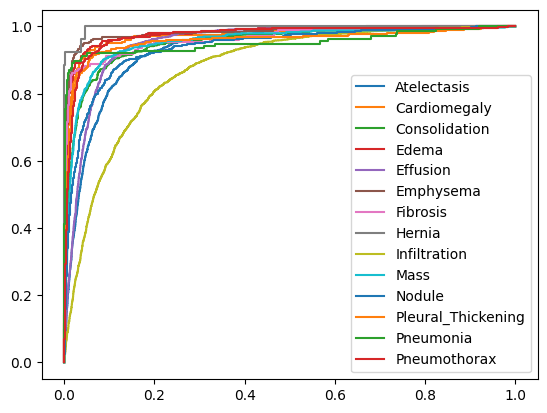

In [61]:
true = true.reshape((11200, 14))
pred = pred.reshape((11200,14))

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

for i,j in enumerate(unique):
    fpr, tpr, _ = roc_curve(true[:,i],pred[:,i])
    plt.plot(fpr,tpr, label = j)
    plt.legend()

In [65]:
roc_scores = unique
for i,j in enumerate(unique):
    roc_scores[j] = roc_auc_score(true[:,i],pred[:,i])

In [67]:
roc_scores

{'Atelectasis': 0.9314776443709588,
 'Cardiomegaly': 0.9741630864690839,
 'Consolidation': 0.9540728857767973,
 'Edema': 0.9787993041298104,
 'Effusion': 0.950778551708478,
 'Emphysema': 0.9821974185864172,
 'Fibrosis': 0.9630675827281086,
 'Hernia': 0.9966921837782765,
 'Infiltration': 0.8751484739437558,
 'Mass': 0.9549076306941152,
 'Nodule': 0.9382360941431875,
 'Pleural_Thickening': 0.9586070635135313,
 'Pneumonia': 0.9530354602123997,
 'Pneumothorax': 0.973655995471156}